# NLU v1 — Intent & Slot Classification

Objetivo:
- Entrenar un modelo NLU basado en Transformer
- Clasificar intent
- Clasificar period_type
- Clasificar category_hint
- Usar slots semánticos (texto crudo fuera del modelo)

Arquitectura:
- Encoder: paraphrase-multilingual-MiniLM-L12-v2
- Heads:
  - Intent
  - Period Type
  - Category Hint


In [1]:
import pandas as pd
import numpy as np

from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModel,
)


In [2]:
from pathlib import Path
import pandas as pd

# Ruta base = carpeta donde está este archivo
BASE_DIR = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()

# Carpeta data relativa al proyecto
DATA_DIR = BASE_DIR

print("Base dir:", BASE_DIR)
print("Loading data from:", DATA_DIR.resolve())

csv_files = [
    "add_expense.csv",
    "show_movements.csv",
    "add_income.csv",
    "show_balance.csv",
    "show_accounts.csv",
    "show_categories.csv",
    "show_credit_cards.csv",
    "help.csv",
    "smalltalk.csv",
]

dfs = []

for file in csv_files:
    path = DATA_DIR / file

    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")

    df = pd.read_csv(path)
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

print("Total rows loaded:", len(data))


Base dir: /content
Loading data from: /content
Total rows loaded: 502


In [3]:
data.head()
data.tail()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   text           502 non-null    object
 1   intent         502 non-null    object
 2   period_type    502 non-null    object
 3   period_text    223 non-null    object
 4   category_hint  502 non-null    object
 5   category_text  194 non-null    object
 6   amount_text    146 non-null    object
 7   account_text   37 non-null     object
dtypes: object(8)
memory usage: 31.5+ KB


# Limpieza de datos

In [4]:
# Normalizar texto
data["text"] = data["text"].str.strip().str.lower()

# Reemplazar NaN por None explícito
data = data.where(pd.notnull(data), None)

# Validacion

In [5]:
REQUIRED_COLUMNS = [
    "text",
    "intent",
    "period_type",
    "category_hint",
]

missing = [c for c in REQUIRED_COLUMNS if c not in data.columns]
assert not missing, f"Faltan columnas: {missing}"

# Reglas de coherencia

In [6]:
# period_type NONE -> period_text debe ser None
invalid_period = data[
    (data["period_type"] == "NONE") & (data["period_text"].notnull())
]

# category_hint NONE -> category_text debe ser None
invalid_category = data[
    (data["category_hint"] == "NONE") & (data["category_text"].notnull())
]

print("Period inválidos:", len(invalid_period))
print("Category inválidos:", len(invalid_category))

Period inválidos: 0
Category inválidos: 0


# Exploración y visualización de datos

## Distribución de intents

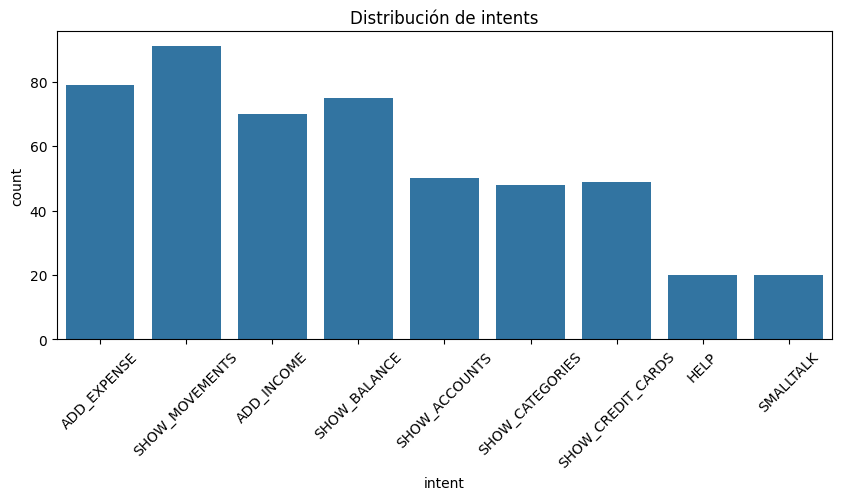

In [7]:
plt.figure(figsize=(10, 4))
sns.countplot(data=data, x="intent")
plt.xticks(rotation=45)
plt.title("Distribución de intents")
plt.show()

## Period types

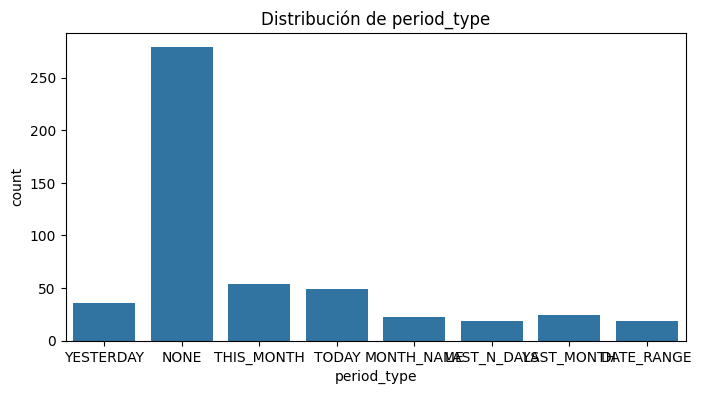

In [8]:
plt.figure(figsize=(8, 4))
sns.countplot(data=data, x="period_type")
plt.title("Distribución de period_type")
plt.show()

## Category hints

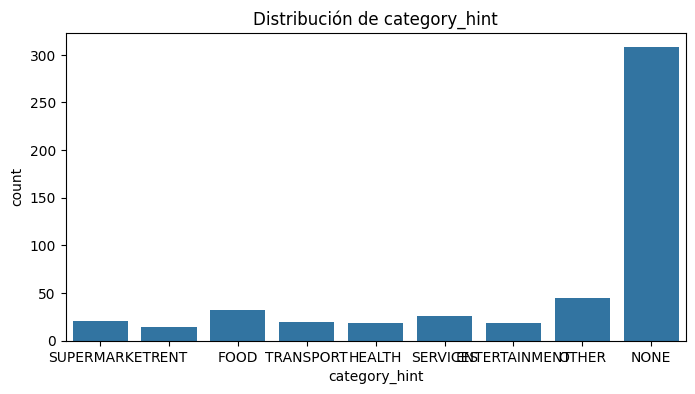

In [9]:
plt.figure(figsize=(8, 4))
sns.countplot(data=data, x="category_hint")
plt.title("Distribución de category_hint")
plt.show()

# Encoding de labels

In [10]:
intent_encoder = LabelEncoder()
period_encoder = LabelEncoder()
category_encoder = LabelEncoder()

data["intent_label"] = intent_encoder.fit_transform(data["intent"])
data["period_label"] = period_encoder.fit_transform(data["period_type"])
data["category_label"] = category_encoder.fit_transform(data["category_hint"])

In [11]:
intent_mapping = dict(zip(intent_encoder.classes_, intent_encoder.transform(intent_encoder.classes_)))
period_mapping = dict(zip(period_encoder.classes_, period_encoder.transform(period_encoder.classes_)))
category_mapping = dict(zip(category_encoder.classes_, category_encoder.transform(category_encoder.classes_)))

intent_mapping, period_mapping, category_mapping

({'ADD_EXPENSE': np.int64(0),
  'ADD_INCOME': np.int64(1),
  'HELP': np.int64(2),
  'SHOW_ACCOUNTS': np.int64(3),
  'SHOW_BALANCE': np.int64(4),
  'SHOW_CATEGORIES': np.int64(5),
  'SHOW_CREDIT_CARDS': np.int64(6),
  'SHOW_MOVEMENTS': np.int64(7),
  'SMALLTALK': np.int64(8)},
 {'DATE_RANGE': np.int64(0),
  'LAST_MONTH': np.int64(1),
  'LAST_N_DAYS': np.int64(2),
  'MONTH_NAME': np.int64(3),
  'NONE': np.int64(4),
  'THIS_MONTH': np.int64(5),
  'TODAY': np.int64(6),
  'YESTERDAY': np.int64(7)},
 {'ENTERTAINMENT': np.int64(0),
  'FOOD': np.int64(1),
  'HEALTH': np.int64(2),
  'NONE': np.int64(3),
  'OTHER': np.int64(4),
  'RENT': np.int64(5),
  'SERVICES': np.int64(6),
  'SUPERMARKET': np.int64(7),
  'TRANSPORT': np.int64(8)})

# Split train / validation

In [12]:
train_df, val_df = train_test_split(
    data,
    test_size=0.2,
    stratify=data["intent"],
    random_state=42,
)

# Tokenizer

In [13]:
MODEL_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

In [14]:
sample = train_df.iloc[0]["text"]
tokenizer(sample, truncation=True, padding=True)

{'input_ids': [0, 13042, 57529, 370, 272, 22, 22574, 473, 2409, 2], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

# PyTorch


## Dataset

In [15]:
class NLUDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=64):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        encoding = self.tokenizer(
            row["text"],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt",
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "intent_label": torch.tensor(row["intent_label"], dtype=torch.long),
            "period_label": torch.tensor(row["period_label"], dtype=torch.long),
            "category_label": torch.tensor(row["category_label"], dtype=torch.long),
        }


In [16]:
BATCH_SIZE = 16

train_dataset = NLUDataset(train_df, tokenizer)
val_dataset = NLUDataset(val_df, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

# Modelo

In [17]:
class NLUMultiHeadModel(nn.Module):
    def __init__(
        self,
        model_name: str,
        num_intents: int,
        num_periods: int,
        num_categories: int,
        hidden_size: int = 384,
        dropout: float = 0.2,
    ):
        super().__init__()

        self.encoder = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)

        self.intent_head = nn.Linear(hidden_size, num_intents)
        self.period_head = nn.Linear(hidden_size, num_periods)
        self.category_head = nn.Linear(hidden_size, num_categories)

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )

        pooled = outputs.last_hidden_state[:, 0]  # [CLS]
        pooled = self.dropout(pooled)

        return {
            "intent_logits": self.intent_head(pooled),
            "period_logits": self.period_head(pooled),
            "category_logits": self.category_head(pooled),
        }

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = NLUMultiHeadModel(
    model_name=MODEL_NAME,
    num_intents=len(intent_encoder.classes_),
    num_periods=len(period_encoder.classes_),
    num_categories=len(category_encoder.classes_),
)

model.to(device)

model.safetensors:   0%|          | 0.00/471M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


NLUMultiHeadModel(
  (encoder): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(250037, 384, padding_idx=0)
      (position_embeddings): Embedding(512, 384)
      (token_type_embeddings): Embedding(2, 384)
      (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=384, out_features=384, bias=True)
              (key): Linear(in_features=384, out_features=384, bias=True)
              (value): Linear(in_features=384, out_features=384, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=384, out_features=384, bias=True)
              (LayerNorm): LayerNorm((384,), eps=1e-12, element

In [19]:
criterion = nn.CrossEntropyLoss()

def compute_loss(outputs, batch):
    loss_intent = criterion(outputs["intent_logits"], batch["intent_label"])
    loss_period = criterion(outputs["period_logits"], batch["period_label"])
    loss_category = criterion(outputs["category_logits"], batch["category_label"])

    return loss_intent + loss_period + loss_category

In [20]:
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

In [21]:
EPOCHS = 5

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for batch in train_loader:
        optimizer.zero_grad()

        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
        )

        loss = compute_loss(outputs, batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
            )

            loss = compute_loss(outputs, batch)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)

    print(
        f"Epoch {epoch + 1}/{EPOCHS} "
        f"| Train Loss: {avg_train_loss:.4f} "
        f"| Val Loss: {avg_val_loss:.4f}"
    )

Epoch 1/5 | Train Loss: 5.6897 | Val Loss: 4.6653
Epoch 2/5 | Train Loss: 4.2183 | Val Loss: 3.7200
Epoch 3/5 | Train Loss: 3.4200 | Val Loss: 3.0726
Epoch 4/5 | Train Loss: 2.8112 | Val Loss: 2.5950
Epoch 5/5 | Train Loss: 2.4155 | Val Loss: 2.2673


In [22]:
def accuracy(preds, labels):
    return (preds == labels).mean()

model.eval()

intent_preds, intent_labels = [], []
period_preds, period_labels = [], []
category_preds, category_labels = [], []

with torch.no_grad():
    for batch in val_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
        )

        intent_preds.extend(outputs["intent_logits"].argmax(dim=1).cpu().numpy())
        intent_labels.extend(batch["intent_label"].cpu().numpy())

        period_preds.extend(outputs["period_logits"].argmax(dim=1).cpu().numpy())
        period_labels.extend(batch["period_label"].cpu().numpy())

        category_preds.extend(outputs["category_logits"].argmax(dim=1).cpu().numpy())
        category_labels.extend(batch["category_label"].cpu().numpy())

print("Intent accuracy:", accuracy(np.array(intent_preds), np.array(intent_labels)))
print("Period accuracy:", accuracy(np.array(period_preds), np.array(period_labels)))
print("Category accuracy:", accuracy(np.array(category_preds), np.array(category_labels)))


Intent accuracy: 0.9405940594059405
Period accuracy: 0.801980198019802
Category accuracy: 0.7920792079207921


In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [24]:
def plot_confusion(y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred, labels=range(len(labels)))

    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels
    )
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(title)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

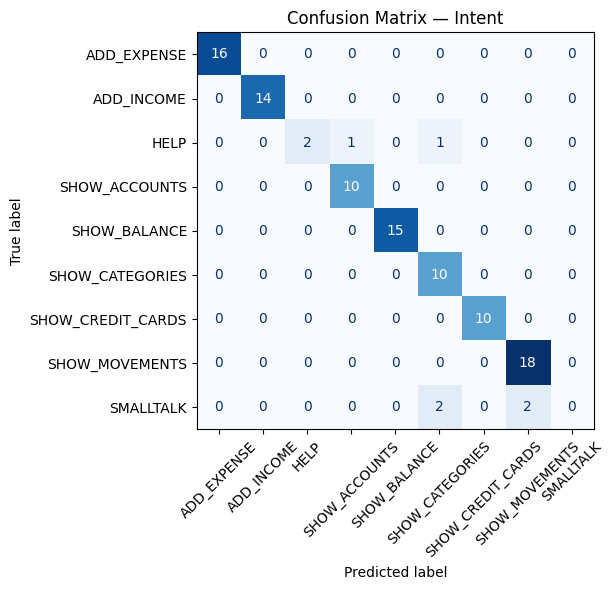

In [25]:
plot_confusion(
    y_true=intent_labels,
    y_pred=intent_preds,
    labels=intent_encoder.classes_,
    title="Confusion Matrix — Intent"
)

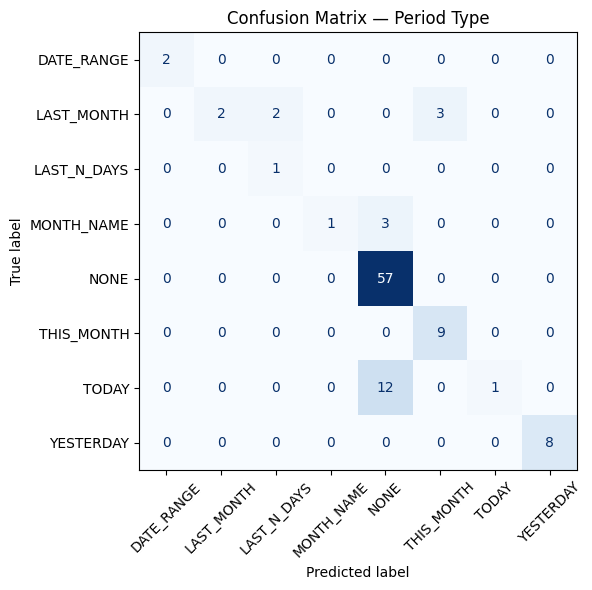

In [26]:
plot_confusion(
    y_true=period_labels,
    y_pred=period_preds,
    labels=period_encoder.classes_,
    title="Confusion Matrix — Period Type"
)

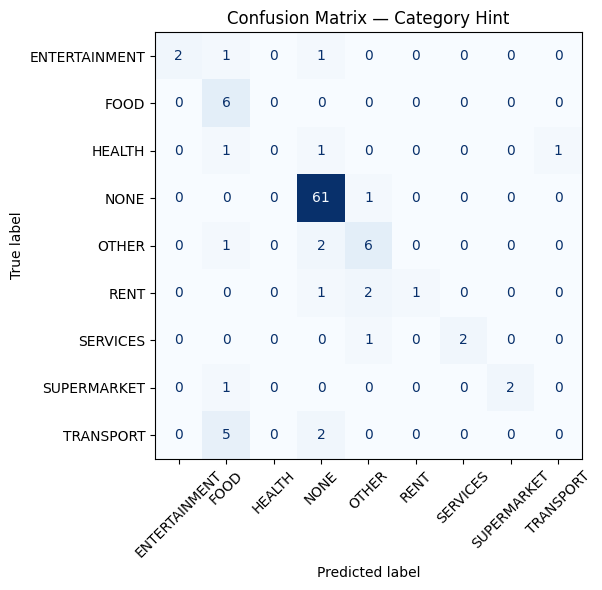

In [27]:
plot_confusion(
    y_true=category_labels,
    y_pred=category_preds,
    labels=category_encoder.classes_,
    title="Confusion Matrix — Category Hint"
)

# CONFIDENCE REAL (SOFTMAX) + CALIBRACIÓN BÁSICA

## Inferencia con confidences (validation set)

In [28]:
import torch.nn.functional as F

def softmax_confidence(logits):
    """
    Devuelve:
    - pred_idx: índice de la clase ganadora
    - confidence: probabilidad softmax de esa clase
    """
    probs = F.softmax(logits, dim=1)
    conf, pred = torch.max(probs, dim=1)
    return pred.cpu().numpy(), conf.cpu().numpy()

In [29]:
model.eval()

intent_preds, intent_confs = [], []
period_preds, period_confs = [], []
category_preds, category_confs = [], []

with torch.no_grad():
    for batch in val_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
        )

        ip, ic = softmax_confidence(outputs["intent_logits"])
        pp, pc = softmax_confidence(outputs["period_logits"])
        cp, cc = softmax_confidence(outputs["category_logits"])

        intent_preds.extend(ip)
        intent_confs.extend(ic)

        period_preds.extend(pp)
        period_confs.extend(pc)

        category_preds.extend(cp)
        category_confs.extend(cc)

## Distribución de confidences

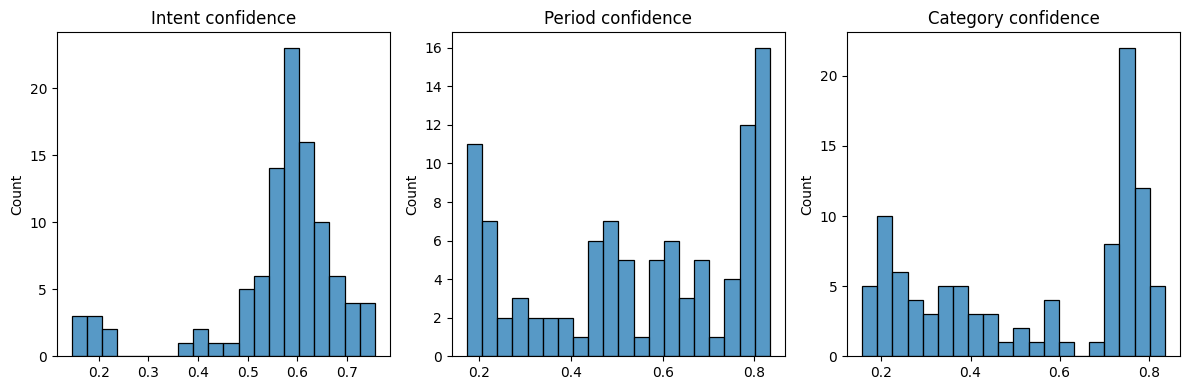

In [30]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
sns.histplot(intent_confs, bins=20)
plt.title("Intent confidence")

plt.subplot(1, 3, 2)
sns.histplot(period_confs, bins=20)
plt.title("Period confidence")

plt.subplot(1, 3, 3)
sns.histplot(category_confs, bins=20)
plt.title("Category confidence")

plt.tight_layout()
plt.show()

## Confidence vs Accuracy (sanity check)

In [31]:
def accuracy_at_threshold(preds, labels, confs, threshold):
    mask = confs >= threshold
    if mask.sum() == 0:
        return None
    return (preds[mask] == labels[mask]).mean(), mask.sum()

In [32]:
intent_labels_np = np.array(intent_labels)
intent_preds_np = np.array(intent_preds)
intent_confs_np = np.array(intent_confs)

for t in [0.6, 0.7, 0.75, 0.8, 0.85]:
    acc, count = accuracy_at_threshold(
        intent_preds_np,
        intent_labels_np,
        intent_confs_np,
        t
    )
    print(f"Threshold {t}: accuracy={acc}, samples={count}")

Threshold 0.6: accuracy=1.0, samples=42
Threshold 0.7: accuracy=1.0, samples=8
Threshold 0.75: accuracy=1.0, samples=2


TypeError: cannot unpack non-iterable NoneType object

### Thresholds para slots

In [33]:
period_labels_np = np.array(period_labels)
period_preds_np = np.array(period_preds)
period_confs_np = np.array(period_confs)

category_labels_np = np.array(category_labels)
category_preds_np = np.array(category_preds)
category_confs_np = np.array(category_confs)

for t in [0.6, 0.7, 0.75]:
    p_acc, p_count = accuracy_at_threshold(
        period_preds_np, period_labels_np, period_confs_np, t
    )
    c_acc, c_count = accuracy_at_threshold(
        category_preds_np, category_labels_np, category_confs_np, t
    )
    print(
        f"Threshold {t} | "
        f"Period acc={p_acc}, samples={p_count} | "
        f"Category acc={c_acc}, samples={c_count}"
    )

Threshold 0.6 | Period acc=1.0, samples=48 | Category acc=1.0, samples=49
Threshold 0.7 | Period acc=1.0, samples=33 | Category acc=1.0, samples=47
Threshold 0.75 | Period acc=1.0, samples=30 | Category acc=1.0, samples=32


# EXPORT + INFERENCIA (PRODUCCIÓN READY)

In [34]:
from pathlib import Path
import json

ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)

In [35]:
torch.save(model.state_dict(), ARTIFACTS_DIR / "nlu_model_v1.pt")

In [36]:
label_mappings = {
    "intent": list(intent_encoder.classes_),
    "period_type": list(period_encoder.classes_),
    "category_hint": list(category_encoder.classes_),
}

with open(ARTIFACTS_DIR / "label_mappings.json", "w", encoding="utf-8") as f:
    json.dump(label_mappings, f, indent=2, ensure_ascii=False)

In [37]:
def load_nlu_model(artifacts_dir: Path):
    with open(artifacts_dir / "label_mappings.json", "r", encoding="utf-8") as f:
        mappings = json.load(f)

    model = NLUMultiHeadModel(
        model_name=MODEL_NAME,
        num_intents=len(mappings["intent"]),
        num_periods=len(mappings["period_type"]),
        num_categories=len(mappings["category_hint"]),
    )

    model.load_state_dict(
        torch.load(artifacts_dir / "nlu_model_v1.pt", map_location=device)
    )
    model.to(device)
    model.eval()

    return model, mappings

In [38]:
def predict(text: str, model, tokenizer, mappings):
    encoding = tokenizer(
        text.strip().lower(),
        truncation=True,
        padding="max_length",
        max_length=64,
        return_tensors="pt",
    )

    encoding = {k: v.to(device) for k, v in encoding.items()}

    with torch.no_grad():
        outputs = model(
            input_ids=encoding["input_ids"],
            attention_mask=encoding["attention_mask"],
        )

    ip, ic = softmax_confidence(outputs["intent_logits"])
    pp, pc = softmax_confidence(outputs["period_logits"])
    cp, cc = softmax_confidence(outputs["category_logits"])

    return {
        "intent": mappings["intent"][ip[0]],
        "intent_confidence": float(ic[0]),

        "period_type": mappings["period_type"][pp[0]],
        "period_confidence": float(pc[0]),

        "category_hint": mappings["category_hint"][cp[0]],
        "category_confidence": float(cc[0]),
    }

In [39]:
model_loaded, mappings = load_nlu_model(ARTIFACTS_DIR)

predict(
    "gasté 2500 en supermercado ayer",
    model_loaded,
    tokenizer,
    mappings
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


{'intent': 'ADD_EXPENSE',
 'intent_confidence': 0.5070688128471375,
 'period_type': 'YESTERDAY',
 'period_confidence': 0.5283635854721069,
 'category_hint': 'SUPERMARKET',
 'category_confidence': 0.43270376324653625}